In [5]:
import nmrglue as ng
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm
import pandas as pd


def bruker_to_pipe(bruker_path):
    # read in the Bruker data
    dic,data = ng.bruker.read_pdata(bruker_path)
    u = ng.bruker.guess_udic(dic, data)
    

    left_1h = dic['procs']['OFFSET']    
    sw_ppm_1h = dic['procs']['SW_p']/u[1]['obs']
    right_1h = left_1h - sw_ppm_1h


    left_15n = dic['proc2s']['OFFSET']
    sw_ppm_15n = dic['proc2s']['SW_p']/u[0]['obs']
    right_15n = left_15n - sw_ppm_15n

   

        # Direct Dimsion                       #Indirect Dimension
    ##u[1]['size']     = 768              ;  u[0]['size']     = 600
    ##u[1]['complex']  = True             ;  u[0]['complex']  = True 
    ##u[1]['encoding'] = 'direct'         ;  u[0]['encoding'] = 'states'
    ##u[1]['sw']       = 11061.947        ;  u[0]['sw']       = 4000.000
    ##u[1]['obs']      = 800.134          ;  u[0]['obs']      = 201.204
    ##u[1]['car']      = 4.7 * 800.134  ;  u[0]['car']      = 58.742 * 201.204
    ##u[1]['label']    = '1H'             ;  u[0]['label']    = '13C'            
    ##
    # create the converter object and initilize with Bruker data
    C = ng.convert.converter()
    C.from_bruker(dic, data, u)

    # create NMRPipe data and then write it out
    ng.pipe.write("2d_pipe.ft", *C.to_pipe(), overwrite=True)
    return left_1h, right_1h, left_15n, right_15n


def convert_peak_names(ccpn_names):
    aa_codes = {
    'ALA': 'A',  # Alanine
    'ARG': 'R',  # Arginine
    'ASN': 'N',  # Asparagine
    'ASP': 'D',  # Aspartic acid
    'CYS': 'C',  # Cysteine
    'GLN': 'Q',  # Glutamine
    'GLU': 'E',  # Glutamic acid
    'GLY': 'G',  # Glycine
    'HIS': 'H',  # Histidine
    'ILE': 'I',  # Isoleucine
    'LEU': 'L',  # Leucine
    'LYS': 'K',  # Lysine
    'MET': 'M',  # Methionine
    'PHE': 'F',  # Phenylalanine
    'PRO': 'P',  # Proline
    'SER': 'S',  # Serine
    'THR': 'T',  # Threonine
    'TRP': 'W',  # Tryptophan
    'TYR': 'Y',  # Tyrosine
    'VAL': 'V'   # Valine
    }
    new_names = []
    for i in ccpn_names:
        if '@' in i:
            new_names.append('')
        else:
            isplit = i.split('.')
            aa_three = isplit[2]
            num = isplit[1]
            atom = isplit[3]
            if atom is not 'H':
                sc = 'sc'
            else:
                sc = ''
            aa_one = aa_codes[aa_three]
            new_names.append(f'{aa_one}{num}{sc}')
    return new_names



<>:75: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:75: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
/tmp/ipykernel_78789/2968668440.py:75: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if atom is not 'H':


/home/courtade/miniforge3/envs/py3/lib/python3.13/site-packages/nmrglue/fileio/convert.py:68: UserWarning: Incompatible dtypes, conversion not recommended
  warn("Incompatible dtypes, conversion not recommended")
/home/courtade/miniforge3/envs/py3/lib/python3.13/site-packages/matplotlib/contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/home/courtade/miniforge3/envs/py3/lib/python3.13/site-packages/matplotlib/contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/home/courtade/miniforge3/envs/py3/lib/python3.13/site-packages/numpy/ma/core.py:2892: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
/tmp/ipykernel_78789/2879717392.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout

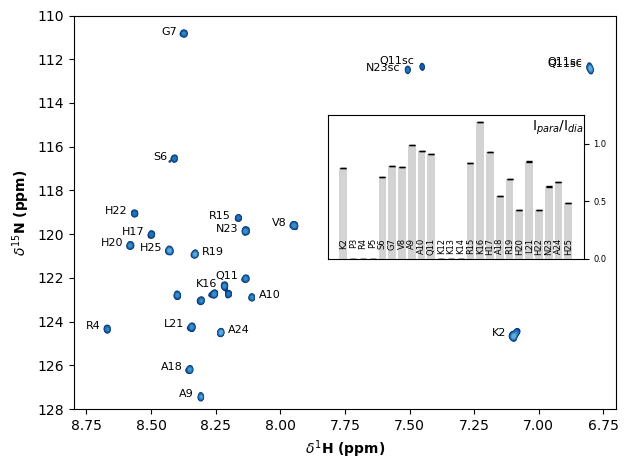

In [ ]:
pdata_path = '8/pdata/1'
left_1h, right_1h, left_15n, right_15n = bruker_to_pipe(pdata_path)

# plot parameters
cmap = matplotlib.cm.Blues_r    # contour map (colors to use for contours)
contour_start = 4e3         # contour level start value
contour_num = 10                # number of contour levels
contour_factor = 1.20           # scaling factor between contour levels

# calculate contour levels
cl = [contour_start * contour_factor ** x for x in range(contour_num)]

# read in the data from a NMRPipe file

dic, data = ng.pipe.read("2d_pipe.ft")



# read peaks from ccpnTable

# Extract peak names and coordinates
df =  pd.read_excel('ccpnTable_15N-HSQC.xlsx')
peaks = df[["Assign F1", "Pos F1", "Pos F2"]].dropna()

# Plot
#plt.figure(figsize=(8,6))
#plt.scatter(peaks["Pos F1"], peaks["Pos F2"], c="blue", alpha=0.7)

peaks['Labels'] = convert_peak_names(peaks["Assign F1"])

# Label peaks with names
for _, row in peaks.iterrows():
    shift=0.03
    shifty=0
    this_label = str(row['Labels'])
    if this_label in ['A10', 'A24', 'R19']:
        shift = -0.11
    if this_label in ['Q11sc']:
        shifty = -0.2
    plt.text(row["Pos F1"]+shift, row["Pos F2"]+shifty, this_label, fontsize=8, ha="right")


# plot the contours
#ax.contour(data, cl, cmap=cmap)
plt.contour(data, cl, cmap=cmap, extent=(left_1h, right_1h, left_15n, right_15n))
plt.ylabel(r"$\delta^{15}$N (ppm)", fontweight='bold')
plt.xlabel(r"$\delta^{1}$H (ppm)", fontweight='bold')
plt.xlim(8.8, 6.7)
plt.ylim(128, 110)
#ax['a'].text(8.362, 122.483+shift, "x", size=16, color='r')
data = pd.read_csv('I_ratio_data.txt', sep='\t', comment='#').to_numpy()
a = plt.axes([0.52, 0.45, 0.4, .3])
plt.bar(data[:,1], data[:,2], yerr=data[:,3], capsize=2, color='lightgrey')
#plt.xlim(0, 0.2)
plt.xticks(rotation=90, fontsize=6)
# yticks and label on right side
a.yaxis.tick_right()
a.yaxis.set_label_position('right')
a.tick_params(axis='x', direction='in', length=0, pad=-15)
plt.yticks([0.0, 0.5, 1.0], fontsize=6)
a.set_title('I$_{para}$/I$_{dia}$', fontsize=10, x=0.9, y=0.85, ha='center', va='center')
plt.tight_layout()
plt.savefig('hsqc.pdf', dpi=300)
plt.savefig('hsqc.png', dpi=300)
plt.show()



In [37]:
data[:,2]

array([0.7864866508102812, 0.0, 0.0, 0.0, 0.7081577355228422,
       0.8041024513224514, 0.7984897443840234, 0.9851002528787522,
       0.9372656136586884, 0.9074388654853942, 0.0, 0.0, 0.0,
       0.8300012681791767, 1.188674554594612, 0.9290784709535876,
       0.5474564347939053, 0.6922295196689984, 0.426336705850904,
       0.8452328791979367, 0.4246692811607904, 0.6287096887890584,
       0.66388961471376, 0.483130456451495], dtype=object)

In [30]:
convert_peak_names(peaks["Assign F1"])

@-.@3..H
@-.@7..H
@-.@9..H
@-.@10..H
@-.@11..H
@-.@18..H
A.4.ARG.H
A.6.SER.H
A.7.GLY.H
A.8.VAL.H
A.9.ALA.H
A.10.ALA.H
A.11.GLN.H
A.11.GLN.HE21
A.11.GLN.HE22
A.15.ARG.H
A.16.LYS.H
A.17.HIS.H
A.18.ALA.H
A.19.ARG.H
A.20.HIS.H
A.21.LEU.H
A.22.HIS.H
A.23.ASN.HD21
A.23.ASN.HD22
A.24.ALA.H
A.25.HIS.H
